Dataset loaded successfully.
Running GridSearchCV...

Best Parameters:
{'classifier__C': 1, 'classifier__solver': 'lbfgs'}
Best Cross-Validated ROC-AUC: 0.8454
Training the model...


c:\Users\Neelesh_New\OneDrive - Queen Mary, University of London\Customer Churn Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Neelesh_New\OneDrive - Queen Mary, University of London\Customer Churn Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Neelesh_New\OneDrive - Queen Mary, University of London\Customer Churn Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



--- Final Model Evaluation ---
Accuracy: 0.7601

Precision: 0.5359
Recall: 0.7193
F1-Score: 0.6142
ROC-AUC Score: 0.8401
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.83      1035
           1       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[802 233]
 [105 269]]


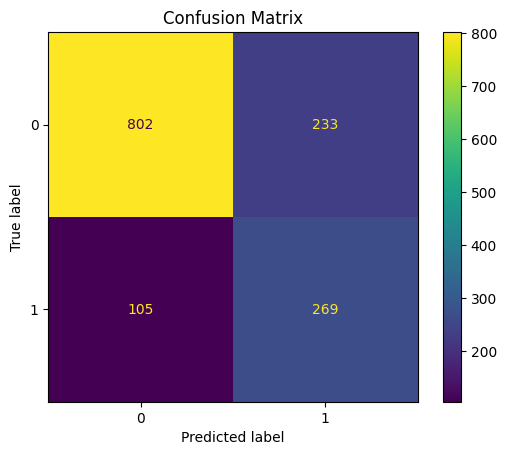


ROC-AUC Score: 0.8401


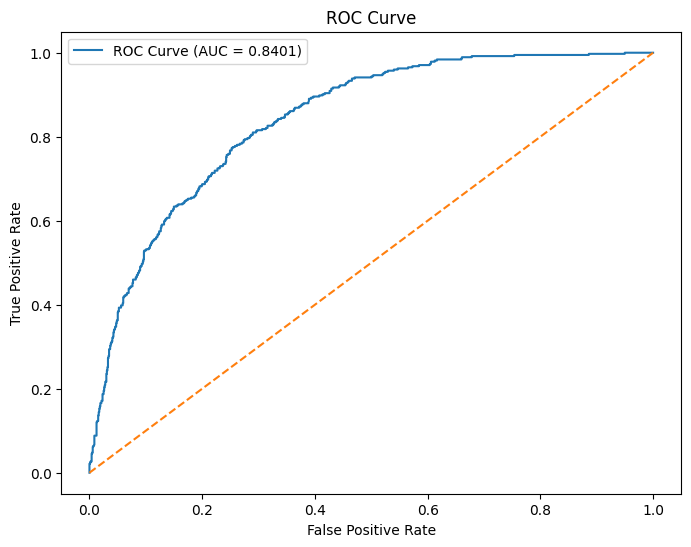


--- Metrics Summary Table ---
      Metric     Score
0   Accuracy  0.760114
1  Precision  0.535857
2     Recall  0.719251
3   F1 Score  0.614155
4    ROC-AUC  0.840122


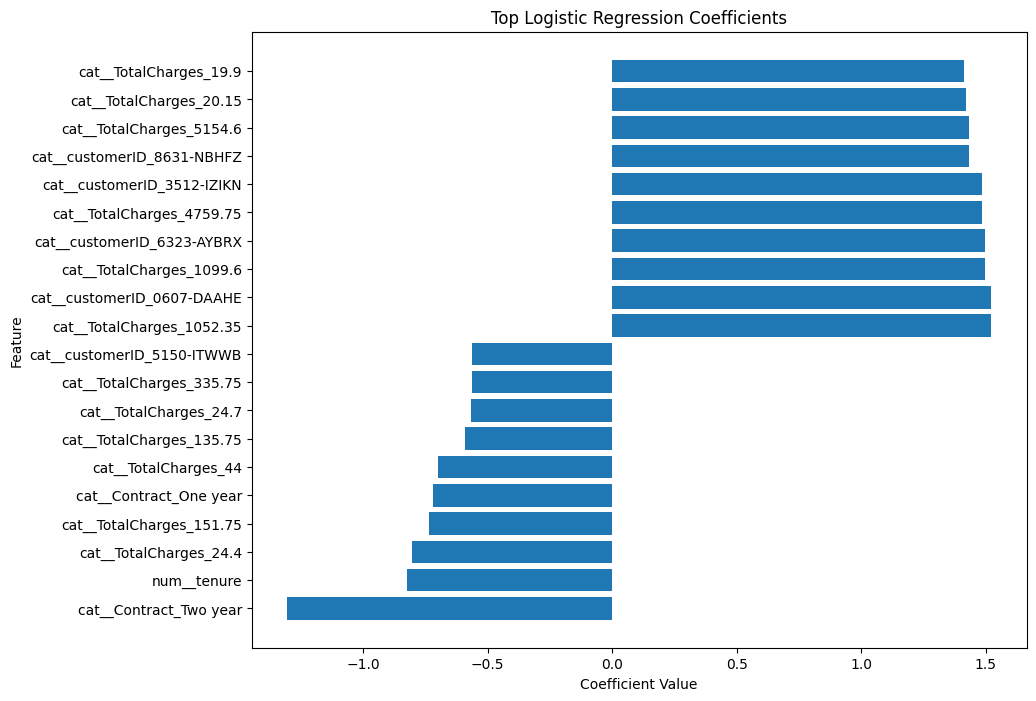

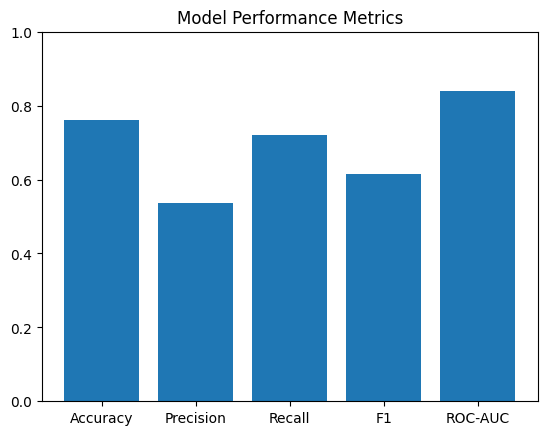

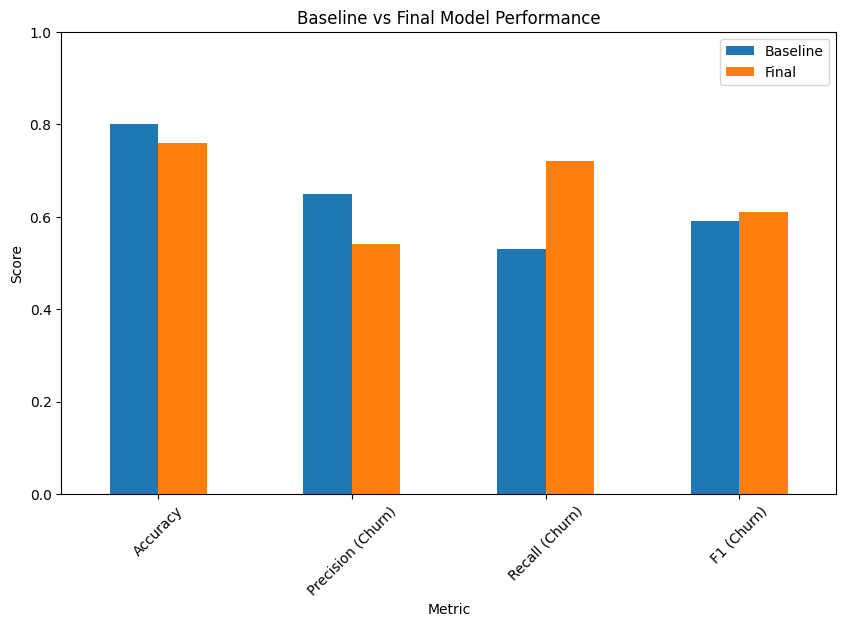

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# 1. Load the Dataset
df = pd.read_csv("Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully.")

# 2. Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0, 1: 1, 0: 0})

# 3. Identify column types
categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# 4. Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 5. Full model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    ))
])
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"]
}

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 7. Hyperparameter tuning with GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Running GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")
# 8. Train model
print("Training the model...")
model.fit(X_train, y_train)

# 9. Predict
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 10. Evaluate
print("\n--- Final Model Evaluation ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy: {accuracy:.4f}\n")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

results_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

print("\n--- Metrics Summary Table ---")
print(results_summary)

# Extract feature names after preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Extract Logistic Regression coefficients
coefficients = best_model.named_steps["classifier"].coef_[0]

# Create dataframe of coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Top positive and negative coefficients
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(10)

# Combine for plotting
top_features = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
values = [accuracy, precision, recall, f1, roc_auc]

plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylim(0, 1)
plt.show()

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "F1 (Churn)"],
    "Baseline": [0.8013, 0.65, 0.53, 0.59],
    "Final": [0.7601, 0.54, 0.72, 0.61]
})

comparison_df.set_index("Metric").plot(kind="bar", figsize=(10, 6))
plt.title("Baseline vs Final Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()